<a href="https://colab.research.google.com/github/Ashwin-2408/Tensor_Flow_Learning/blob/main/notebooks/Transfer_Learning_Feature_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning

Transfer Learning is leveraging a  working existing model architecture and learned patterns for our problem

## Downloading Data

In [1]:
! wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

--2025-06-20 08:00:48--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.199.207, 192.178.163.207, 74.125.20.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.199.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M   113MB/s    in 1.4s    

2025-06-20 08:00:50 (113 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [2]:
import zipfile
zipref=zipfile.ZipFile("/content/10_food_classes_10_percent.zip")
zipref.extractall()
zipref.close()

In [3]:
import os

for dirpath,dirnames,filenames in os.walk("/content/10_food_classes_10_percent"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in the directory '{dirpath}'.")

There are 2 directories and 0 images in the directory '/content/10_food_classes_10_percent'.
There are 10 directories and 0 images in the directory '/content/10_food_classes_10_percent/test'.
There are 0 directories and 250 images in the directory '/content/10_food_classes_10_percent/test/ramen'.
There are 0 directories and 250 images in the directory '/content/10_food_classes_10_percent/test/ice_cream'.
There are 0 directories and 250 images in the directory '/content/10_food_classes_10_percent/test/hamburger'.
There are 0 directories and 250 images in the directory '/content/10_food_classes_10_percent/test/steak'.
There are 0 directories and 250 images in the directory '/content/10_food_classes_10_percent/test/grilled_salmon'.
There are 0 directories and 250 images in the directory '/content/10_food_classes_10_percent/test/fried_rice'.
There are 0 directories and 250 images in the directory '/content/10_food_classes_10_percent/test/chicken_wings'.
There are 0 directories and 250 imag

## Preparing the Data

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE=32
IMAGE_SIZE=[224,224]

Train_Data_Generator=ImageDataGenerator(rescale=1/255.)
Test_Data_Generator=ImageDataGenerator(rescale=1/255.)

Train_Directory="/content/10_food_classes_10_percent/train"
Test_Directory="/content/10_food_classes_10_percent/test"

Train_Data=Train_Data_Generator.flow_from_directory(Train_Directory,batch_size=BATCH_SIZE,target_size=IMAGE_SIZE,class_mode="categorical")
Test_Data=Test_Data_Generator.flow_from_directory(Test_Directory,batch_size=BATCH_SIZE,target_size=IMAGE_SIZE,class_mode="categorical")

Found 750 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


## Setting up Callbacks : Things to run when our model trains

Callbacks are extra functionality that we can add to our models,whilst they train or after training.Popular Callbacks are:

* Tracking Experiments with the TensorBoard CallBack
* Model checkpoint with the ModelCheckPoint Callback
* Stopping a model from training(before it runs long and overfits) with the EarlyStopping Callback

In [5]:
#Create TensorBoardCallback (functionized because we need to create a new_one for each model)
import datetime

def create_tensor_board_callback(dir_name,experiment_name):
  log_dir=dir_name +"/" + experiment_name +"/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback=tf_keras.callbacks.TensorBoard(log_dir=log_dir)
  print(f"Saving tensorboard log files to : {log_dir}")
  return tensorboard_callback

## Creating Models Using Tensorflow Hub




In [6]:
#comparing the two models

res_net_model_url = "https://www.kaggle.com/models/google/resnet-v2/TensorFlow2/50-classification/2"
efficient_net_url="https://www.kaggle.com/models/tensorflow/efficientnet/TensorFlow2/b0-classification/1"

In [7]:
import tensorflow as tf
import tensorflow_hub as hub
import tf_keras


In [8]:
# Let's create a create_model() function to create a model from a URL
import tensorflow as tf
import tensorflow_hub as hub

# Make sure you're using the right imports
def create_model(model_url, max_classes=10):
    feature_extractor_layer = hub.KerasLayer(
        model_url,
        trainable=False,
        name="feature_extraction_layer",
        input_shape=(224, 224, 3)
    )

    model = tf_keras.Sequential([
        feature_extractor_layer,
        tf_keras.layers.Flatten(),
        tf_keras.layers.Dense(max_classes, activation="softmax", name="output_layer")
    ])
    return model


In [9]:
res_net_model=create_model(res_net_model_url)

In [10]:
res_net_model.compile(loss=tf.keras.losses.CategoricalCrossentropy(),optimizer=tf_keras.optimizers.Adam(),metrics=["accuracy"])
res_net_history=res_net_model.fit(Train_Data,epochs=5,steps_per_epoch=len(Train_Data),validation_data=Test_Data,validation_steps=len(Test_Data),callbacks=[create_tensor_board_callback(dir_name="tensorhub",experiment_name="resnet")])

Saving tensorboard log files to : tensorhub/resnet/20250620-080107
Epoch 1/5
24/24 [==============================] - 22s 609ms/step - loss: 2.2021 - accuracy: 0.3800 - val_loss: 1.1901 - val_accuracy: 0.6120
Epoch 2/5
24/24 [==============================] - 12s 535ms/step - loss: 0.9611 - accuracy: 0.6987 - val_loss: 0.9077 - val_accuracy: 0.7004
Epoch 3/5
24/24 [==============================] - 13s 554ms/step - loss: 0.6875 - accuracy: 0.7867 - val_loss: 0.8308 - val_accuracy: 0.7216
Epoch 4/5
24/24 [==============================] - 10s 415ms/step - loss: 0.5448 - accuracy: 0.8333 - val_loss: 0.8032 - val_accuracy: 0.7260
Epoch 5/5
24/24 [==============================] - 9s 400ms/step - loss: 0.4333 - accuracy: 0.8787 - val_loss: 0.7842 - val_accuracy: 0.7360


In [11]:
res_net_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 feature_extraction_layer (  (None, 1001)              25615849  
 KerasLayer)                                                     
                                                                 
 flatten (Flatten)           (None, 1001)              0         
                                                                 
 output_layer (Dense)        (None, 10)                10020     
                                                                 
Total params: 25625869 (97.75 MB)
Trainable params: 10020 (39.14 KB)
Non-trainable params: 25615849 (97.72 MB)
_________________________________________________________________


## Creating A Function to plot our loss curves

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
def plot_loss_curve(history):
  x=pd.DataFrame(history.history)
  plt.figure(figsize=(12,6))
  plt.subplot(1,2,1)
  plt.title("LOSS")
  plt.plot(x['loss'],label="loss curve")
  plt.plot(x['val_loss'],label="validation_loss_curve")
  plt.xlabel("Epochs")
  plt.legend()
  plt.subplot(1,2,2)
  plt.title("Accuracy")
  plt.plot(x['accuracy'],label="accuracy curve")
  plt.plot(x['val_accuracy'],label="validation_accuracy_curve")
  plt.xlabel("Epochs")
  plt.legend()
  plt.tight_layout()


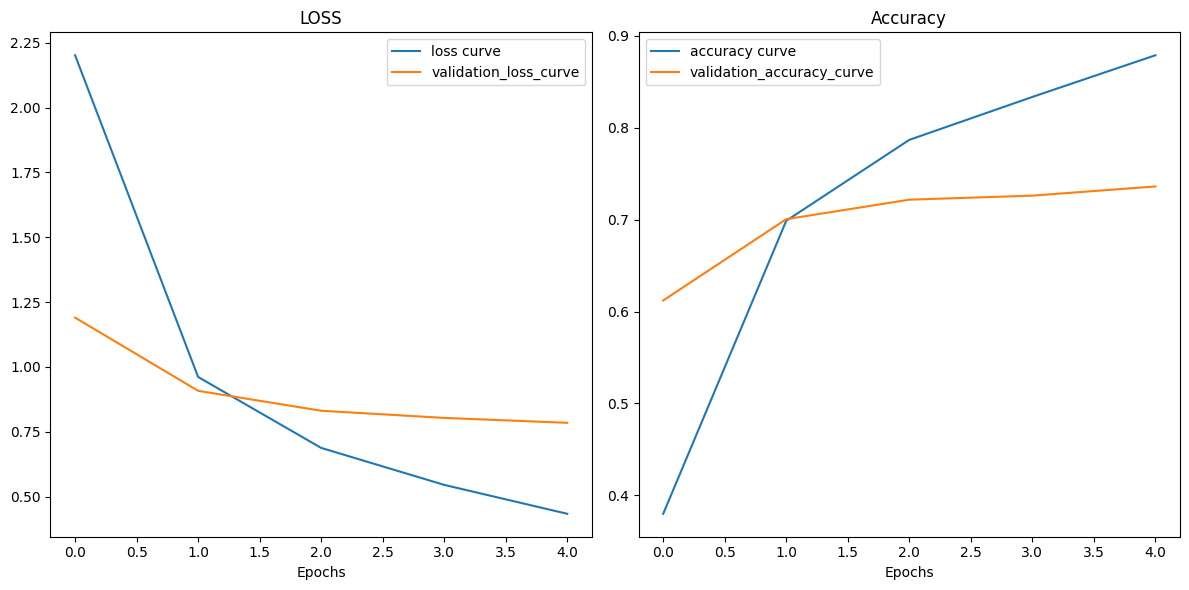

In [19]:
plot_loss_curve(res_net_history)

## Creating and Testing EfficientNet Feature Extraction Model

In [20]:
efficient_net_model=create_model(efficient_net_url)

In [21]:
efficient_net_model.compile(loss=tf_keras.losses.CategoricalCrossentropy(),optimizer=tf_keras.optimizers.Adam(),metrics=["accuracy"])

In [22]:
efficient_net_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 feature_extraction_layer (  (None, 1000)              5330564   
 KerasLayer)                                                     
                                                                 
 flatten_1 (Flatten)         (None, 1000)              0         
                                                                 
 output_layer (Dense)        (None, 10)                10010     
                                                                 
Total params: 5340574 (20.37 MB)
Trainable params: 10010 (39.10 KB)
Non-trainable params: 5330564 (20.33 MB)
_________________________________________________________________


In [25]:
efficient_net_history=efficient_net_model.fit(Train_Data,epochs=5,steps_per_epoch=len(Train_Data),validation_data=Test_Data,validation_steps=len(Test_Data))

Epoch 1/5
24/24 [==============================] - 28s 623ms/step - loss: 2.2981 - accuracy: 0.1853 - val_loss: 2.2911 - val_accuracy: 0.1964
Epoch 2/5
24/24 [==============================] - 12s 520ms/step - loss: 2.2850 - accuracy: 0.2507 - val_loss: 2.2764 - val_accuracy: 0.3236
Epoch 3/5
24/24 [==============================] - 12s 507ms/step - loss: 2.2673 - accuracy: 0.4173 - val_loss: 2.2611 - val_accuracy: 0.4136
Epoch 4/5
24/24 [==============================] - 9s 391ms/step - loss: 2.2561 - accuracy: 0.5040 - val_loss: 2.2466 - val_accuracy: 0.5616
Epoch 5/5
24/24 [==============================] - 9s 376ms/step - loss: 2.2412 - accuracy: 0.5947 - val_loss: 2.2324 - val_accuracy: 0.5884


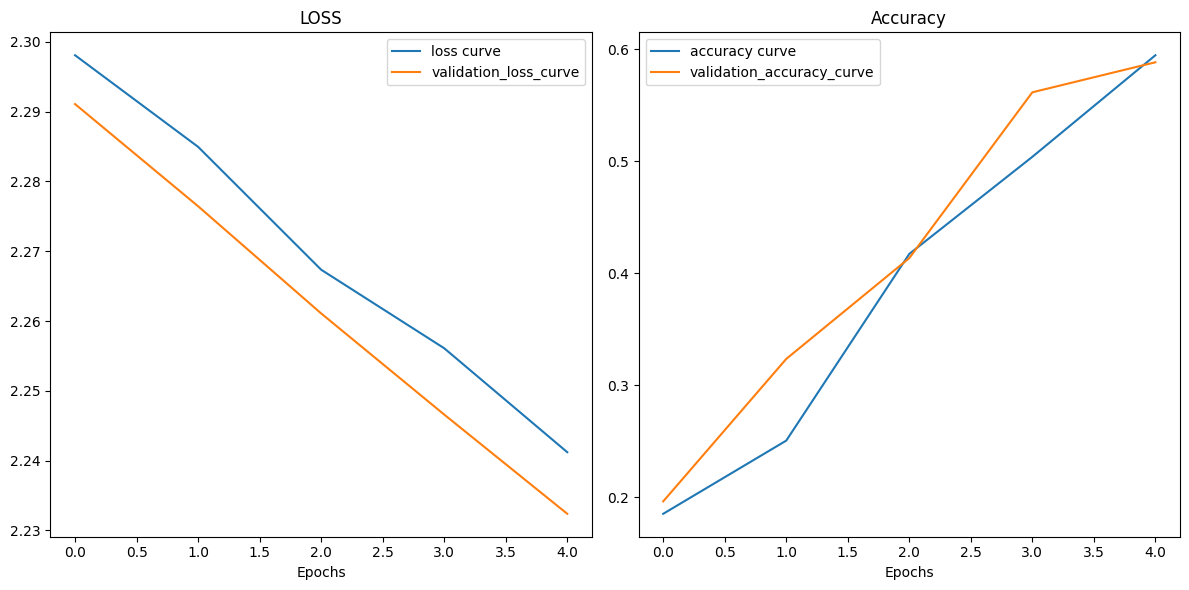

In [26]:
plot_loss_curve(efficient_net_history)